In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import random
import sys
sys.path.append('..')
from config import *

plt.rcParams['figure.dpi'] = 150
print(" Imports done")
print(f"Device: {DEVICE}")

 Imports done
Device: cpu


In [2]:
def load_images(split_dir, class_names):
    paths, labels = [], []
    for idx, cls in enumerate(class_names):
        cls_dir = Path(split_dir) / cls
        imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
        paths.extend(imgs)
        labels.extend([idx] * len(imgs))
    return paths, labels

train_paths, train_labels = load_images(TRAIN_DIR, TUMOR_CLASSES)
test_paths,  test_labels  = load_images(TEST_DIR,  TUMOR_CLASSES)

print(f"Train: {len(train_paths)} | Test: {len(test_paths)}")

Train: 5600 | Test: 1600


In [3]:
train_counts = [train_labels.count(i) for i in range(len(TUMOR_CLASSES))]
test_counts  = [test_labels.count(i)  for i in range(len(TUMOR_CLASSES))]

for cls, cnt in zip(TUMOR_CLASSES, train_counts):
    print(f"  {cls:12s}: {cnt} images ({cnt/len(train_labels)*100:.1f}%)")

  glioma      : 1400 images (25.0%)
  meningioma  : 1400 images (25.0%)
  notumor     : 1400 images (25.0%)
  pituitary   : 1400 images (25.0%)


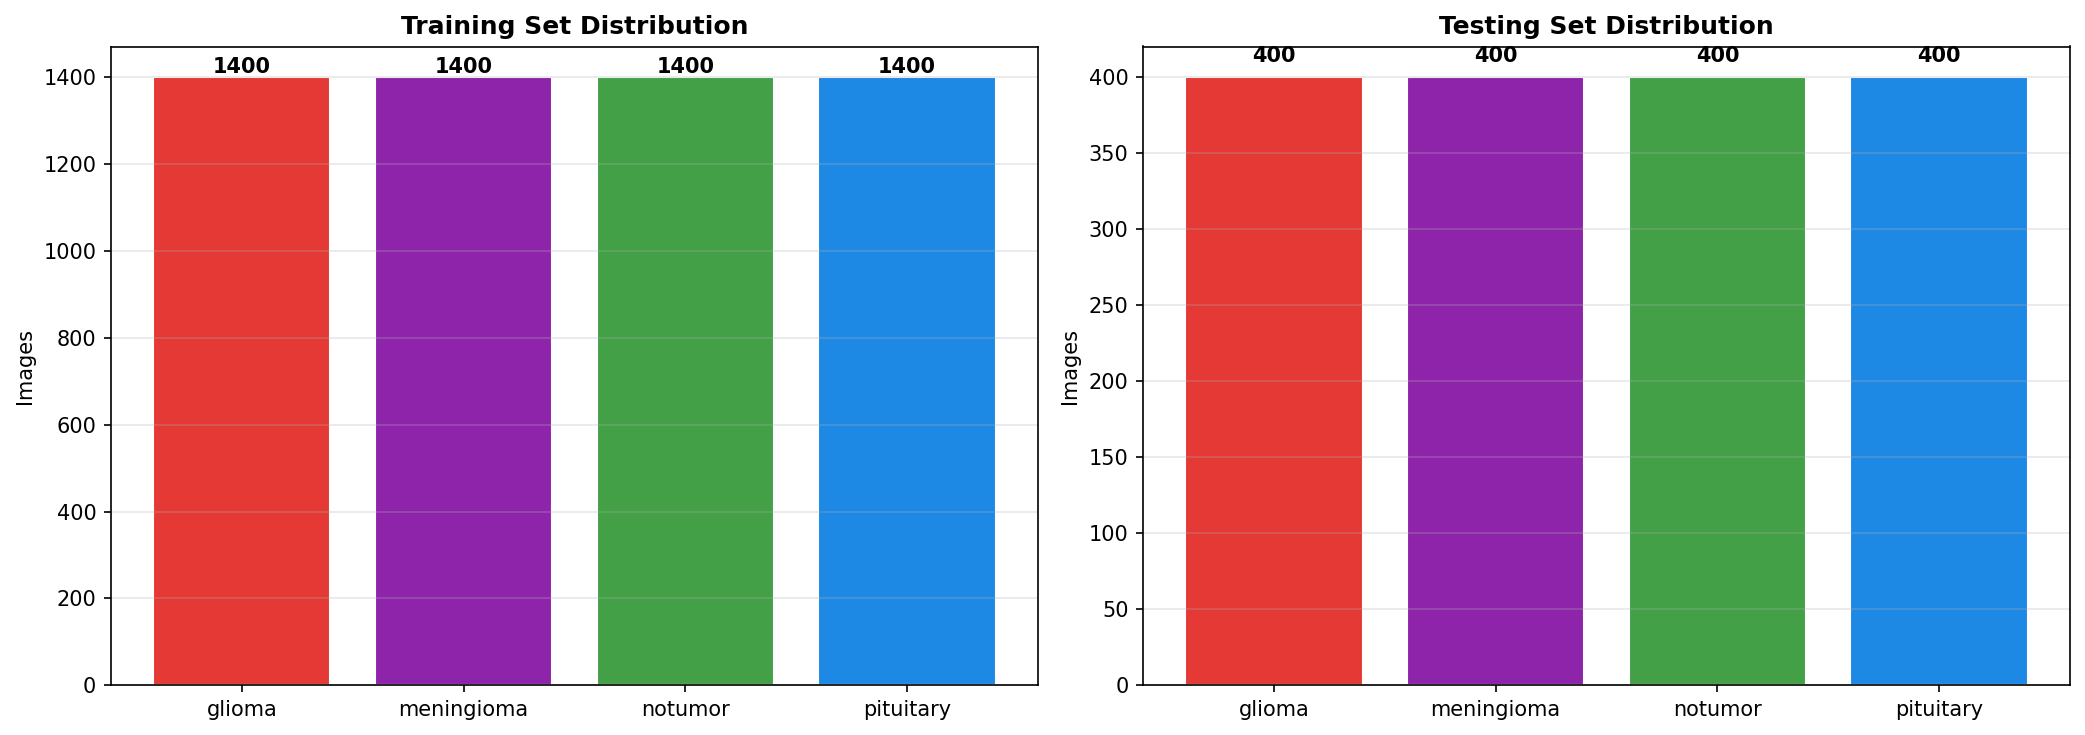

In [4]:
colors = ['#E53935', '#8E24AA', '#43A047', '#1E88E5']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Training', 'Testing']):
    bars = ax.bar(TUMOR_CLASSES, counts, color=colors, edgecolor='white')
    ax.set_title(f'{title} Set Distribution', fontweight='bold')
    ax.set_ylabel('Images')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10,
                str(val), ha='center', fontweight='bold')

plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / 'eda_class_dist.png')
plt.show()

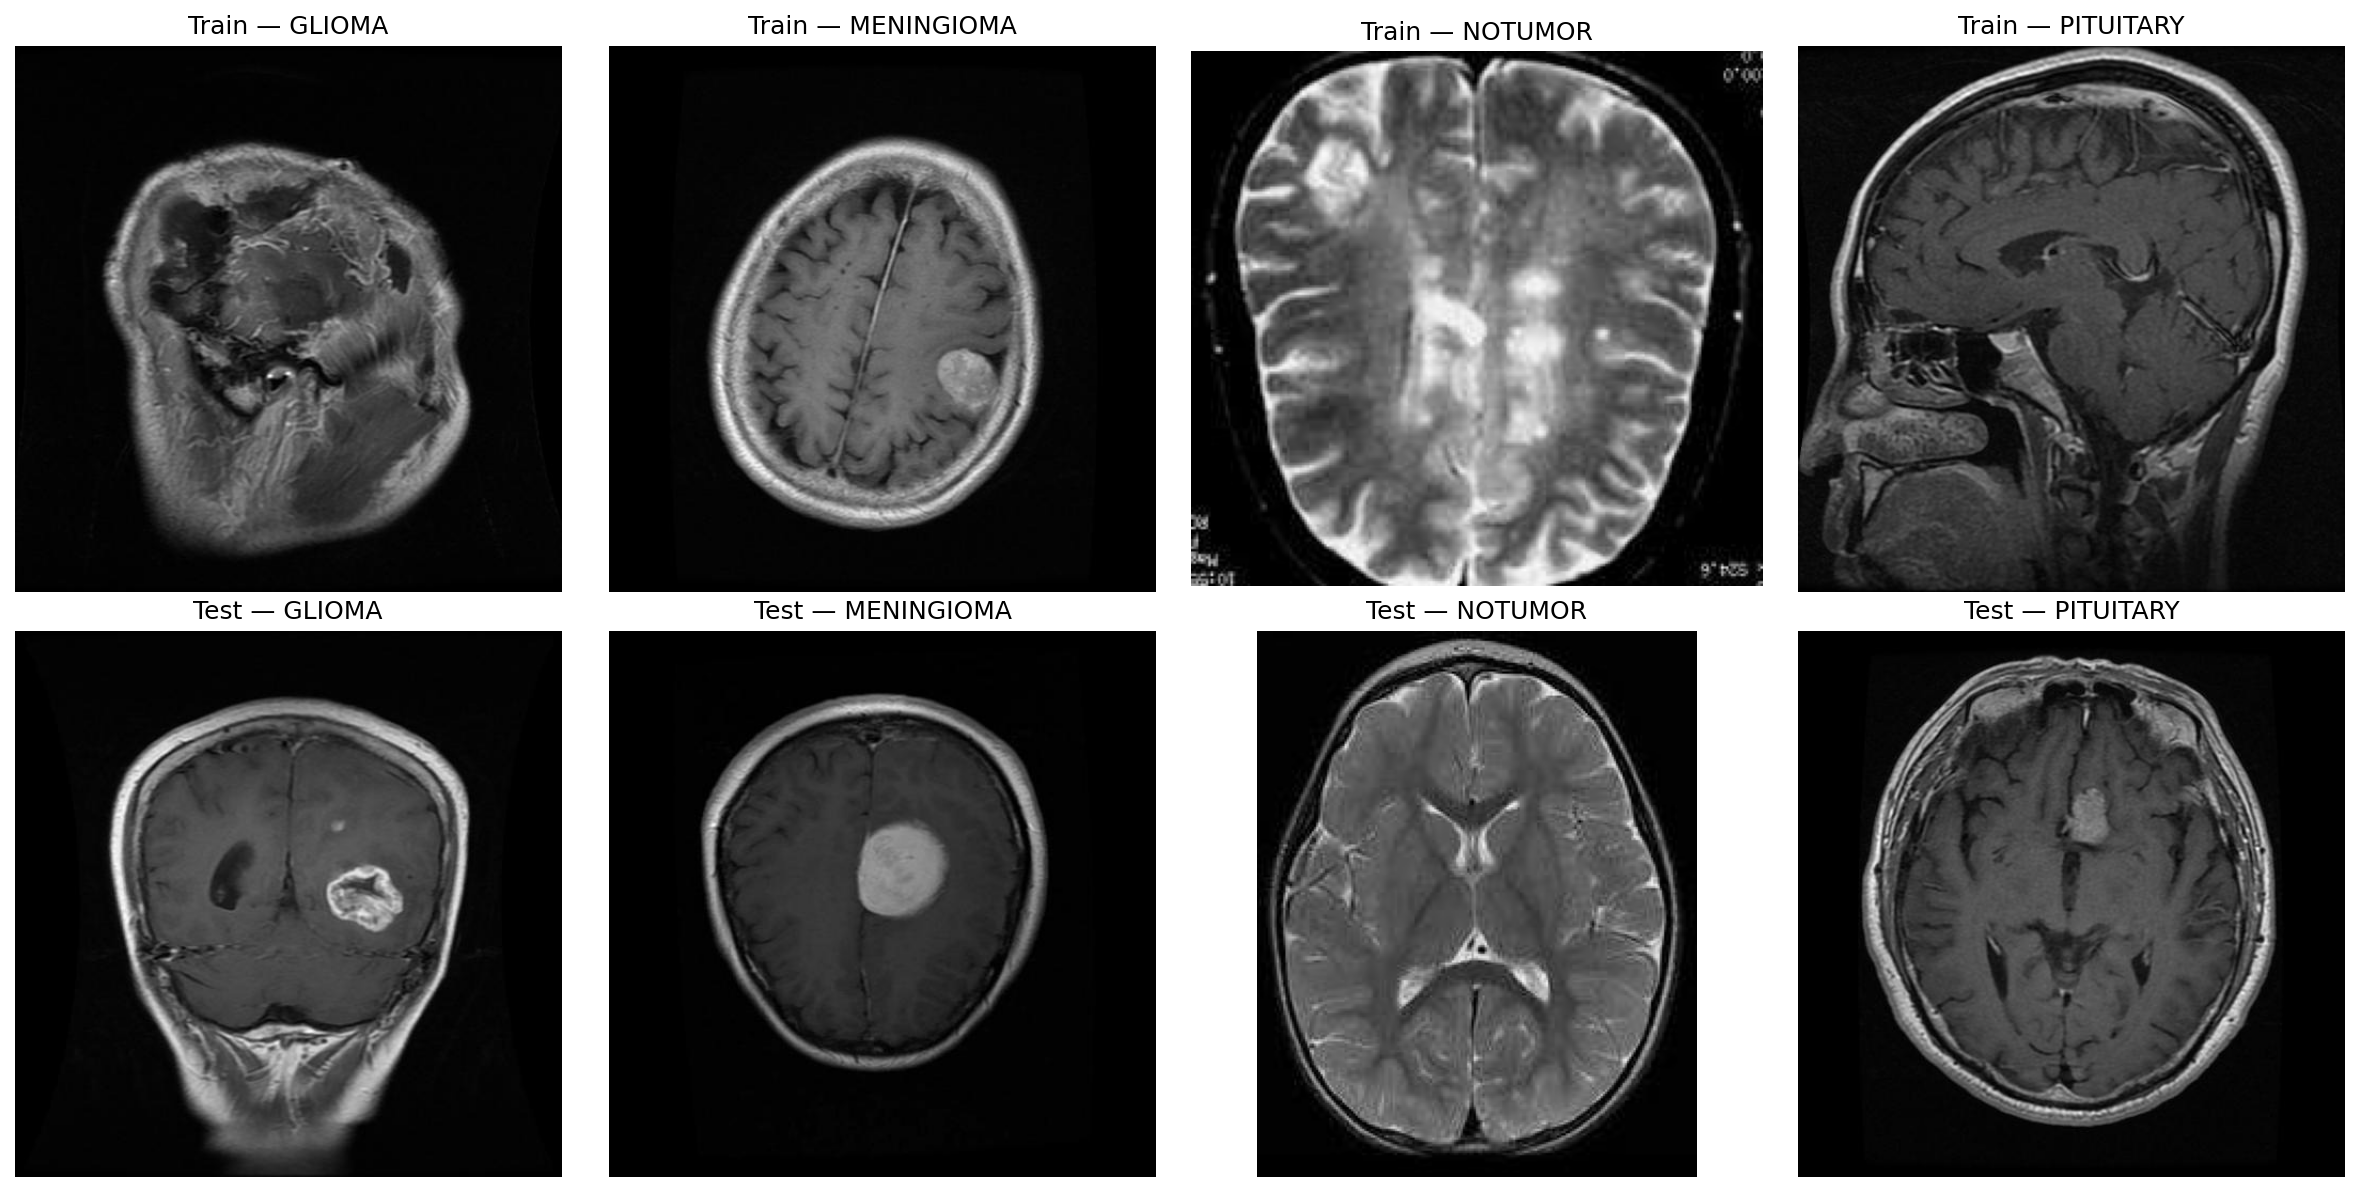

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, (paths, labels, title) in enumerate([
    (train_paths, train_labels, 'Train'),
    (test_paths,  test_labels,  'Test')
]):
    for col, cls in enumerate(TUMOR_CLASSES):
        cls_paths = [p for p, l in zip(paths, labels) if l == col]
        img = Image.open(random.choice(cls_paths)).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(f'{title} — {cls.upper()}')
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_samples.png')
plt.show()

In [6]:
sample = random.sample(train_paths, 200)
widths  = [Image.open(p).size[0] for p in sample]
heights = [Image.open(p).size[1] for p in sample]

print(f"Width  — Min:{min(widths)} Max:{max(widths)} Mean:{np.mean(widths):.1f}")
print(f"Height — Min:{min(heights)} Max:{max(heights)} Mean:{np.mean(heights):.1f}")

Width  — Min:150 Max:1365 Mean:462.6
Height — Min:168 Max:1365 Mean:467.4


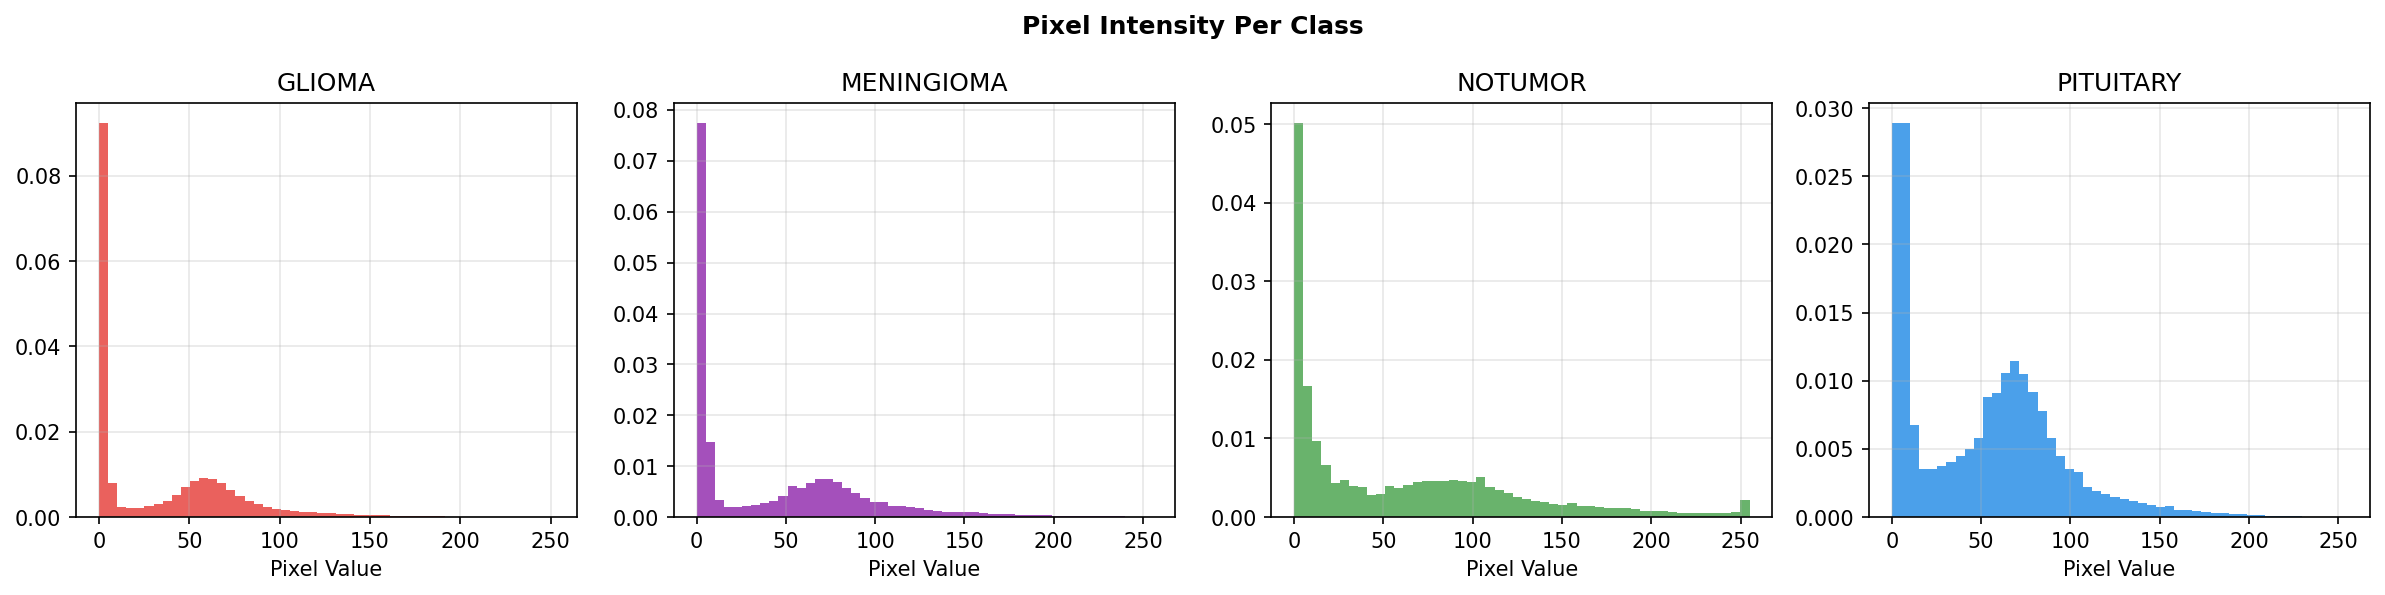

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for col, cls in enumerate(TUMOR_CLASSES):
    cls_paths = [p for p, l in zip(train_paths, train_labels) if l == col]
    sample    = random.sample(cls_paths, 100)
    pixels    = []
    for path in sample:
        arr = np.array(Image.open(path).convert('RGB').resize((224, 224)))
        pixels.extend(arr.flatten().tolist())
    axes[col].hist(pixels, bins=50, color=colors[col], alpha=0.8, density=True)
    axes[col].set_title(cls.upper())
    axes[col].set_xlabel('Pixel Value')
    axes[col].grid(alpha=0.3)

plt.suptitle('Pixel Intensity Per Class', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_pixel_intensity.png')
plt.show()

In [8]:
from torchvision import transforms

tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

sample   = random.sample(train_paths, 500)
mean_sum = np.zeros(3)
std_sum  = np.zeros(3)

for path in sample:
    tensor    = tf(Image.open(path).convert('RGB')).numpy()
    mean_sum += tensor.mean(axis=(1, 2))
    std_sum  += tensor.std(axis=(1, 2))

MEAN_COMPUTED = (mean_sum / len(sample)).tolist()
STD_COMPUTED  = (std_sum  / len(sample)).tolist()

print(f"MEAN : {[round(m, 4) for m in MEAN_COMPUTED]}")
print(f"STD  : {[round(s, 4) for s in STD_COMPUTED]}")
print(" Update config.py with these values")

MEAN : [0.1835, 0.1835, 0.1836]
STD  : [0.1814, 0.1814, 0.1814]
 Update config.py with these values
